## Audio Data Processing in Python

Data source: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle

### Terms to know for Audio in Digital Form:

#### Frequency (Hz)

* Frequency describes the differences of wave lengths.
* We interpret the frequency has high and low pitches.

#### Intensity (db / power)

* Intensity describes the amplitude (height) of the wave.


#### Sample Rate

* Sample rate is specific to how the computer reads in the audio file.
* Think of it as the "resolution" of the audio.

#### Reading in Audio files

There are many types of audio files: `mp3`, `wav`, `m4a`, `flac`, `ogg`

In [3]:
audio_files = glob('archive/*/*.wav')

In [4]:
# Play audio file
ipd.Audio(audio_files[0])

In [6]:
y, sr = librosa.load(audio_files[0])

In [7]:
y

array([-7.6675962e-05, -1.2196129e-04, -1.2175040e-04, ...,
       -2.7837010e-05, -9.6955999e-05,  0.0000000e+00],
      shape=(77989,), dtype=float32)

In [8]:
sr

22050

In [9]:
print(f"y: {y[:10]}")
print(f"shape y: {y.shape}")
print(f"sr: {sr}")

y: [-7.66759622e-05 -1.21961290e-04 -1.21750403e-04 -1.10908892e-04
 -1.18011922e-04 -1.18411052e-04 -9.29638409e-05 -1.16343785e-04
 -1.14297145e-04 -1.12879679e-04]
shape y: (77989,)
sr: 22050


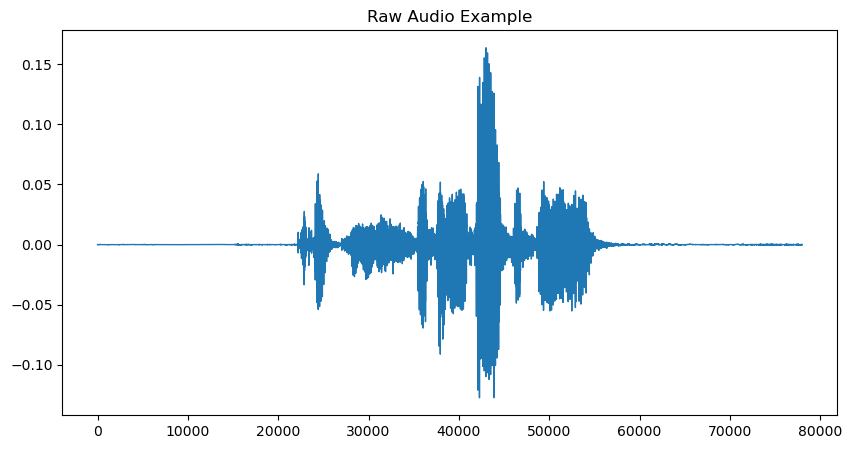

In [13]:
pd.Series(y).plot(figsize=(10,5), lw=1, title='Raw Audio Example')
plt.show()

In [17]:
# Trimming leading/lagging silence
y_trimmed, _ = librosa.effects.trim(y, top_db=20)

In [18]:
y_trimmed

array([ 4.6916761e-05,  4.0431842e-05,  5.2936510e-05, ...,
       -9.1405679e-04, -7.9744402e-04, -9.4812224e-04],
      shape=(33280,), dtype=float32)

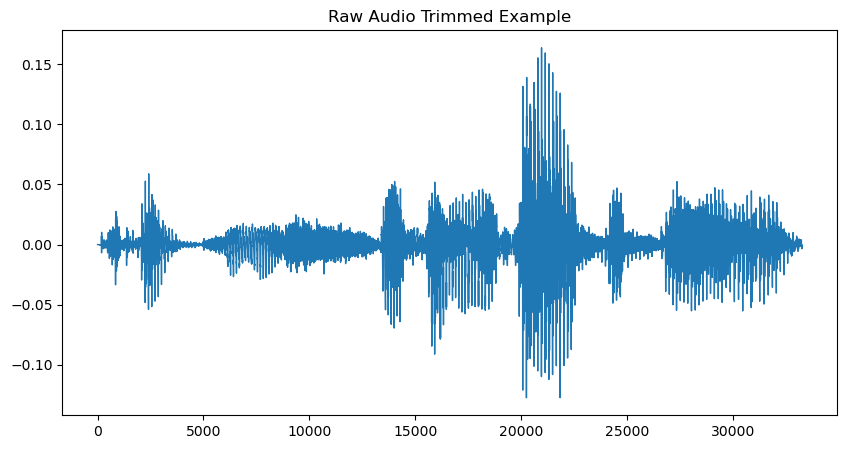

In [19]:
pd.Series(y_trimmed).plot(figsize=(10,5), lw=1, title='Raw Audio Trimmed Example')
plt.show()

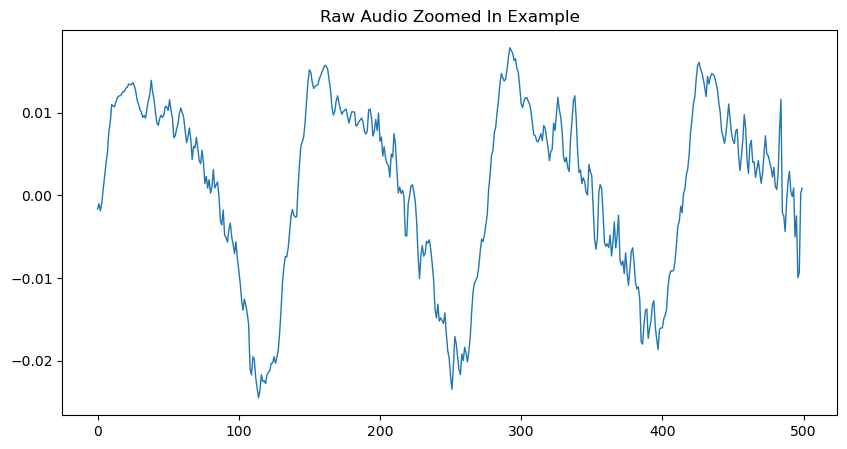

In [22]:
pd.Series(y[30000:30500]).plot(figsize=(10,5), lw=1, title='Raw Audio Zoomed In Example')
plt.show()

#### Spectogram

In [24]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

In [25]:
S_db.shape

(1025, 153)

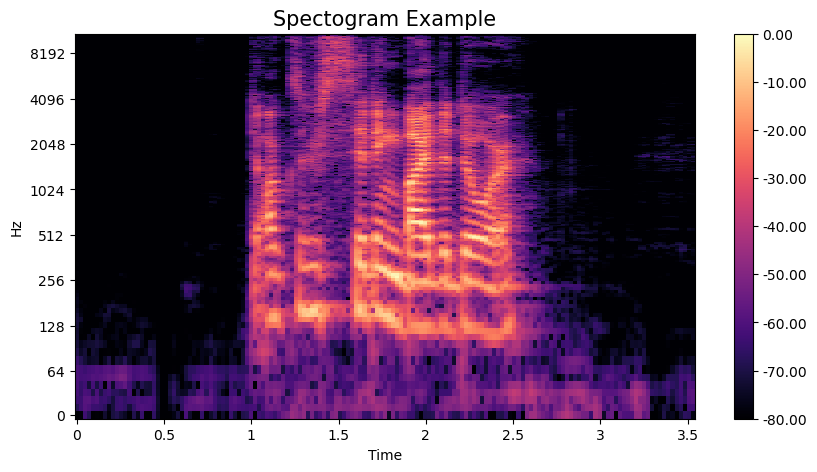

In [29]:
# Plot the transformed audio data
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(S_db, x_axis='time', y_axis='log', ax=ax)

ax.set_title('Spectogram Example', fontsize=15)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

#### Mel Spectogram

In [37]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128*2)

S.shape

(256, 153)

In [38]:
S_db_mel = librosa.amplitude_to_db(S, ref=np.max)

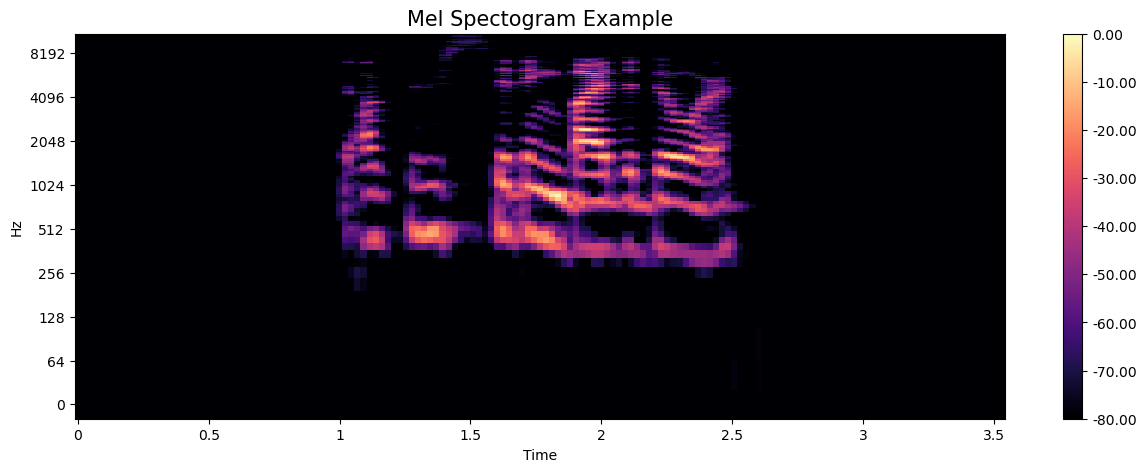

In [39]:
fig, ax = plt.subplots(figsize=(15, 5))

# Plot the mel spectogram
img = librosa.display.specshow(S_db_mel, x_axis='time', y_axis='log', ax=ax)

ax.set_title('Mel Spectogram Example', fontsize=15)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

In [40]:
S_db_mel

array([[-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       ...,
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.]],
      shape=(256, 153), dtype=float32)